# GIN — Fixed Architecture, Configurable Feature Sets (HI-Small)

**Question this notebook answers:** what do manually engineered edge features add when the
GNN architecture is held **exactly fixed**?

The same model class, the same number of layers, the same hidden size, the same MLPs and the
same training recipe are used for every configuration. Three knobs select the experiment:

| Knob | Values | Effect on the model |
|---|---|---|
| `MP_EDGE_FEATS` | `none` / `base` / `full` | `none` → `GINConv`; otherwise `GINEConv(edge_dim)` — identical node MLPs, only the edge term differs |
| `READOUT_EDGE_FEATS` | `base` / `full` / `gfp` | classifier input `[h_src, h_dst, edge feats]`; only its first-layer width changes |
| `MP_DIRECTION` | `in` / `bidirectional` | `in`: embeddings aggregate incoming transactions only (paper's GIN); `bidirectional`: a second conv per layer aggregates outgoing transactions, the two are concatenated → `Linear(128 → 64)` |

`GINConv` **is** `GINEConv` without the edge term (message `ReLU(x_j + e_ij)` vs `x_j`), so
switching between them changes nothing else. Every GIN layer uses the standard node MLP
`Linear → BatchNorm → ReLU → Linear` with learnable ε, a residual connection and dropout.

**This run:** `MP_EDGE_FEATS = none`, `READOUT_EDGE_FEATS = base`, `MP_DIRECTION = in` —
node embeddings come from node features and topology only; the classifier sees the embeddings
plus the 20 baseline transaction features.

**Fixed recipe (Altman et al. 2023):** 2 GIN layers, hidden 64, neighbour sampling `[100, 100]`,
`BCEWithLogits(pos_weight=8)`, Adam lr 1e-3, 20 epochs, threshold chosen on validation,
minority-class F1 as the headline metric. `TEMPORAL_SAMPLING` (only earlier edges are sampled
around a seed edge) is available as a switch, default off for paper comparability.

**Inputs (Kaggle dataset):** `train_graph.pt`, `val_graph.pt`, `test_graph.pt`, `feature_meta.json`
from `Data_preparation.ipynb` (`edge_attr` columns `0:20` = baseline, `20:81` = GFP).

## 0. Environment (Kaggle)

`LinkNeighborLoader` needs `pyg_lib` (or `torch_sparse`). Adjust the wheel URL to the torch /
CUDA version printed in the first line, then **restart the session** after installing.

In [1]:
# import torch
# print('torch', torch.__version__, '| cuda', torch.version.cuda)

# # wheel index must match the torch + CUDA version printed above
# !pip install -q torch_geometric
# !pip install -q pyg_lib torch_scatter torch_sparse -f https://data.pyg.org/whl/torch-2.8.0+cu126.html

In [2]:
!pip uninstall -y torch torchvision torchaudio torch-scatter torch-sparse pyg_lib
!pip install torch==2.8.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126
!pip install torch-scatter torch-sparse torch-cluster -f https://data.pyg.org/whl/torch-2.8.0+cu126.html
!pip install torch_geometric

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu126
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 180.5 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 233.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 144.5 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 87.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 127.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 143.5 MB/s eta 0:00:00a 0:0

## 1. Imports & configuration

In [12]:
import json
import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import (average_precision_score, f1_score, precision_recall_curve,
                             precision_score, recall_score, roc_auc_score)
from torch_geometric.data import Data
from torch_geometric.loader import LinkNeighborLoader
from torch_geometric.nn import GINConv, GINEConv
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'torch {torch.__version__} | device {device}')

torch 2.8.0+cu126 | device cuda


In [13]:
# ---------------- experiment knobs (the ONLY things that change between runs) ----------------
MP_EDGE_FEATS      = 'none'   # 'none' | 'base' | 'full'   edge features used in message passing
READOUT_EDGE_FEATS = 'base'   # 'base' | 'full' | 'gfp'    edge features concatenated in the classifier
MP_DIRECTION       = 'in'     # 'in' | 'bidirectional'     aggregate incoming only, or incoming + outgoing
TEMPORAL_SAMPLING  = False    # True: sample only edges earlier than the seed edge (causal MP)

RUN_NAME = f'gin_mp-{MP_EDGE_FEATS}_readout-{READOUT_EDGE_FEATS}_dir-{MP_DIRECTION}'
if TEMPORAL_SAMPLING:
    RUN_NAME = RUN_NAME + '_temporal'

# ---------------- fixed recipe (Altman et al. 2023) — identical for every run ----------------
HIDDEN        = 64
NUM_LAYERS    = 2
DROPOUT       = 0.3
NUM_NEIGHBORS = [100, 100]     # neighbours sampled per hop (one entry per GNN layer)
BATCH_SIZE    = 8192           # seed edges per mini-batch
EPOCHS        = 20
LR            = 1e-3
WEIGHT_DECAY  = 1e-5
POS_WEIGHT    = 8.0            # weight of the laundering class in the loss
SEED          = 42

# ---------------- paths ----------------
DATA_DIR = '/kaggle/input/datasets/sandrokhizanishvili/hi-small-gnn'   # <- your Kaggle dataset
OUT_DIR  = f'/kaggle/working/outputs/{RUN_NAME}'
os.makedirs(OUT_DIR, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print('run:', RUN_NAME)

run: gin_mp-none_readout-base_dir-in


## 2. Load graphs and pick the feature columns

`feature_meta.json` tells which `edge_attr` columns are baseline (first 20) and GFP (next 61).
Message passing and readout each get their own column list; node features `x` are always used.

In [14]:
train_graph = torch.load(f'{DATA_DIR}/train_graph.pt', weights_only=False)
val_graph   = torch.load(f'{DATA_DIR}/val_graph.pt',   weights_only=False)
test_graph  = torch.load(f'{DATA_DIR}/test_graph.pt',  weights_only=False)
meta = json.load(open(f'{DATA_DIR}/feature_meta.json'))

# column positions of each feature group inside edge_attr
all_cols = meta['EDGE_FEAT_COLS']
base_idx = [all_cols.index(c) for c in meta['BASE_EDGE_COLS']]   # 0..19
gfp_idx  = [all_cols.index(c) for c in meta['GFP_FEAT_COLS']]    # 20..80

column_sets = {
    'none': [],
    'base': base_idx,
    'gfp':  gfp_idx,
    'full': base_idx + gfp_idx,
}
MP_IDX      = column_sets[MP_EDGE_FEATS]        # columns fed to message passing
READOUT_IDX = column_sets[READOUT_EDGE_FEATS]   # columns fed to the classifier
NODE_DIM    = train_graph.x.shape[1]

for name, g in [('train', train_graph), ('val', val_graph), ('test', test_graph)]:
    n_eval = int(g.eval_mask.sum())
    n_pos  = int((g.y[g.eval_mask] == 1).sum())
    print(f'{name:<5} nodes={g.num_nodes:,} edges={g.edge_index.shape[1]:,} '
          f'evaluated={n_eval:,} laundering={n_pos:,} ({n_pos / n_eval:.4%})')

print()
print(f'node features: {NODE_DIM} | MP edge features: {len(MP_IDX)} | readout edge features: {len(READOUT_IDX)}')

train nodes=515,070 edges=3,046,342 evaluated=3,046,342 laundering=2,297 (0.0754%)
val   nodes=515,070 edges=4,061,789 evaluated=1,015,447 laundering=1,082 (0.1066%)
test  nodes=515,070 edges=5,077,237 evaluated=1,015,448 laundering=1,143 (0.1126%)

node features: 6 | MP edge features: 0 | readout edge features: 20


## 3. Model — one class for every configuration

- `node_proj`: `Linear(node_dim → 64)`
- `NUM_LAYERS` × GIN layer. Each conv uses the **same** node MLP
  `Linear(64,64) → BatchNorm → ReLU → Linear(64,64)` with learnable ε. `mp_edge_dim = 0` → `GINConv`,
  otherwise `GINEConv(edge_dim)` (adds only a `Linear(edge_dim → 64)` on the edge term).
  `bidirectional` adds a second conv over reversed edges, merged with `Linear(128 → 64)`.
  Then ReLU, dropout, and the residual connection `h = h + layer(h)`.
- `classifier`: MLP on `[h_src, h_dst, edge feats]` — hidden 64, one logit.

```text
             node features x  [N x 6]
                      |
             Linear 6->64 . ReLU
                      |
        +-------------v-------------+
        | GIN layer 1               |<-- MP edge features e_uv {0|20|81}
        |  m_u = h_u (+ W_e.e_uv)   |    (absent when MP = 'none' -> GINConv;
        |  (1+eps).h_v + sum m_u    |     bidirectional adds a 2nd conv over
        |  MLP: 64->64.BN.ReLU.     |     reversed edges, concat -> 128->64)
        |       64->64              |
        |  ReLU . Dropout . +resid  |
        +-------------+-------------+
        +-------------v-------------+
        | GIN layer 2 (same form)   |<-- e_uv
        +-------------+-------------+
                      |
             embeddings h  [N x 64]
              +-------+-------+
              |               |
          h_s [64]        h_t [64]      seed edge features e_seed {20|81|61}
              |               |             | (raw values, skip MP)
              +-------+-------+             |
                      v                     |
        concat [ h_s || h_t || e_seed ] <---+     width: 64+64+d_seed
                      |
        Linear(128+d_seed -> 64) . ReLU . Dropout . Linear 64->1
                      |
             sigmoid -> P(laundering)
```
Amber rule of the experiment: only `e_uv` width, `e_seed` width (and hence the two input
projections) change between configurations — every other weight shape is identical.

In [15]:
def gin_mlp(hidden):
    '''The MLP "phi" applied after aggregation in every GIN layer.

    Identical in all configurations: Linear 64->64 . BatchNorm . ReLU . Linear 64->64.
    GIN theory needs at least one hidden layer here to keep WL expressiveness;
    BatchNorm tames sum-aggregated activations of hub accounts (degree up to 168k).
    '''
    return nn.Sequential(nn.Linear(hidden, hidden), nn.BatchNorm1d(hidden), nn.ReLU(),
                         nn.Linear(hidden, hidden))


def make_conv(hidden, mp_edge_dim):
    '''One graph convolution; this choice is the ONLY difference between configs.

    mp_edge_dim = 0  -> GINConv : message u->v is  h_u
    mp_edge_dim > 0  -> GINEConv: message u->v is  ReLU(h_u + W_e @ e_uv),
                        with W_e: [hidden, mp_edge_dim] the only extra weight.
    train_eps=True makes eps in (1+eps)*h_v learnable (self vs neighbourhood weight).
    '''
    if mp_edge_dim > 0:
        return GINEConv(gin_mlp(hidden), train_eps=True, edge_dim=mp_edge_dim)
    return GINConv(gin_mlp(hidden), train_eps=True)


class GINLayer(nn.Module):
    '''One message-passing step, optionally in both directions, with a residual.

    Update:   h_v <- h_v + Dropout(ReLU( conv(h, edges) ))
    Conv:     phi( (1+eps)*h_v + sum of messages from neighbours )

    edge_index rows are [senders; receivers] and messages flow sender -> receiver,
    so conv_in makes each account aggregate the accounts that PAID it. With
    bidirectional=True a second conv runs on flipped edges ("whom I paid") and
    the two 64-dim views are merged back to 64.

    Args:
        hidden        (int)  : embedding width (64)
        mp_edge_dim   (int)  : edge feature width in message passing (0 | 20 | 81)
        bidirectional (bool) : add the reverse-direction conv
        dropout       (float): dropout rate after the conv (0.3)
    '''

    def __init__(self, hidden, mp_edge_dim, bidirectional, dropout):
        super().__init__()
        self.use_edges = mp_edge_dim > 0
        self.bidirectional = bidirectional
        self.conv_in = make_conv(hidden, mp_edge_dim)          # "who paid me"
        if bidirectional:
            self.conv_out = make_conv(hidden, mp_edge_dim)     # "whom I paid"
            self.merge = nn.Linear(2 * hidden, hidden)         # concat 64||64 -> 64
        self.dropout = nn.Dropout(dropout)

    def apply_conv(self, conv, h, edge_index, edge_attr):
        '''Route the call: GINEConv takes edge features, GINConv takes none.'''
        if self.use_edges:
            return conv(h, edge_index, edge_attr)
        return conv(h, edge_index)

    def forward(self, h, edge_index, edge_attr):
        '''h: [N, 64] in -> [N, 64] out (refined through the residual).'''
        out = self.apply_conv(self.conv_in, h, edge_index, edge_attr)
        if self.bidirectional:
            # flip(0) swaps senders<->receivers = reversed edges; same edge_attr,
            # a transaction's features describe it in both directions.
            out_rev = self.apply_conv(self.conv_out, h, edge_index.flip(0), edge_attr)
            out = self.merge(torch.cat([out, out_rev], dim=1))
        return h + self.dropout(torch.relu(out))   # residual: refine, don't replace


class GIN(nn.Module):
    '''GIN edge classifier with a fixed architecture.

    Args:
        node_dim         (int)  : raw node feature width (6, entity one-hot)
        mp_edge_dim      (int)  : edge features in message passing (0 | 20 | 81)
        readout_edge_dim (int)  : edge features at the classifier (20 | 81 | 61)
        bidirectional    (bool) : incoming-only vs both-directions aggregation

    Parameter shapes (what "fixed architecture" means concretely):
        node_proj              : [64, node_dim] + [64]
        per layer  - conv MLP  : [64,64]+[64] . BN [64]+[64] . [64,64]+[64], eps scalar
        per layer  - GINE only : W_e [64, mp_edge_dim] + [64]
        per layer  - bidi only : second conv (same shapes) + merge [64, 128] + [64]
        classifier             : [64, 128 + readout_edge_dim] + [64], then [1, 64] + [1]
    Only W_e and the classifier's first layer may change with the feature set.
    '''

    def __init__(self, node_dim, mp_edge_dim, readout_edge_dim, bidirectional):
        super().__init__()
        # embed the 6 entity-type bits into the shared 64-dim working space
        self.node_proj = nn.Linear(node_dim, HIDDEN)
        # NUM_LAYERS (=2) layers of identical structure, each with its own weights
        self.layers = nn.ModuleList(
            [GINLayer(HIDDEN, mp_edge_dim, bidirectional, DROPOUT) for _ in range(NUM_LAYERS)])
        # readout MLP on [h_src || h_dst || raw seed edge features] -> one logit
        self.classifier = nn.Sequential(
            nn.Linear(2 * HIDDEN + readout_edge_dim, HIDDEN), nn.ReLU(), nn.Dropout(DROPOUT),
            nn.Linear(HIDDEN, 1))

    def forward(self, x, edge_index, edge_attr, seed_index, seed_edge_feats):
        '''Score a batch of seed transactions.

        Args (all batch-local, produced by LinkNeighborLoader):
            x               [N, 6]       node features of the sampled subgraph
            edge_index      [2, E]       sampled edges (context + seeds)
            edge_attr       [E, mp_dim]  MP edge features, or None when MP = 'none'
            seed_index      [2, B]       endpoint ids of the B seed transactions
            seed_edge_feats [B, ro_dim]  raw readout features of the seed transactions

        Returns:
            [B] raw logits — BCEWithLogitsLoss / torch.sigmoid apply the sigmoid.
        '''
        # 1) node embeddings by message passing: [N, 6] -> [N, 64], 2 hops of context
        h = torch.relu(self.node_proj(x))
        for layer in self.layers:
            h = layer(h, edge_index, edge_attr)
        # 2) classify each seed s->t from its endpoints + its own raw features
        z = torch.cat([h[seed_index[0]], h[seed_index[1]], seed_edge_feats], dim=1)
        return self.classifier(z).squeeze(-1)      # [B, 1] -> [B]


model = GIN(NODE_DIM, len(MP_IDX), len(READOUT_IDX), MP_DIRECTION == 'bidirectional').to(device)
print(model)

GIN(
  (node_proj): Linear(in_features=6, out_features=64, bias=True)
  (layers): ModuleList(
    (0-1): 2 x GINLayer(
      (conv_in): GINConv(nn=Sequential(
        (0): Linear(in_features=64, out_features=64, bias=True)
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Linear(in_features=64, out_features=64, bias=True)
      ))
      (dropout): Dropout(p=0.3, inplace=False)
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=148, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [16]:
# Architecture fingerprint: parameters that must be IDENTICAL across feature configurations.
# Only two blocks legitimately depend on the feature set: the GINE edge projections
# ('...lin.*') and the classifier's first layer ('classifier.0.*'). Everything else is fixed.
n_params = sum(p.numel() for p in model.parameters())
width_dependent = 0
for name, p in model.named_parameters():
    if '.lin.' in name or name.startswith('classifier.0.'):
        width_dependent += p.numel()
invariant_params = n_params - width_dependent

print(f'total parameters:                  {n_params:,}')
print(f'architecture-invariant parameters: {invariant_params:,}   <- must match across feature configs')

total parameters:                  26,947
architecture-invariant parameters: 17,411   <- must match across feature configs


## 4. Mini-batch loader

`LinkNeighborLoader` samples a 2-hop neighbourhood (`[100, 100]`) around each batch of **seed
edges** (the evaluated edges of the split); the snapshot's context edges are part of the sampled
graph so the model can see history. Message passing uses the `MP_IDX` columns; the seed edges'
`READOUT_IDX` columns are looked up separately through `batch.input_id`.
With `TEMPORAL_SAMPLING`, only edges with `edge_time ≤` the seed edge's time are sampled
(this needs a recent `pyg_lib`; the default off path works with any sampler backend).

In [17]:
def make_loader(g, shuffle):
    # graph used for message passing: node features + (optionally) the MP edge columns
    if len(MP_IDX) > 0:
        mp_edge_attr = g.edge_attr[:, MP_IDX]
    else:
        mp_edge_attr = None
    mp_graph = Data(x=g.x, edge_index=g.edge_index, edge_attr=mp_edge_attr,
                    edge_time=g.edge_time, num_nodes=g.num_nodes)

    # seed edges = the evaluated edges of this split
    seed_mask  = g.eval_mask
    seed_index = g.edge_index[:, seed_mask]
    seed_y     = g.y[seed_mask].float()
    seed_feats = g.edge_attr[seed_mask][:, READOUT_IDX]      # readout features per seed edge

    if TEMPORAL_SAMPLING:
        loader = LinkNeighborLoader(mp_graph, num_neighbors=NUM_NEIGHBORS, batch_size=BATCH_SIZE,
                                    edge_label_index=seed_index, edge_label=seed_y, shuffle=shuffle,
                                    time_attr='edge_time', edge_label_time=g.edge_time[seed_mask])
    else:
        loader = LinkNeighborLoader(mp_graph, num_neighbors=NUM_NEIGHBORS, batch_size=BATCH_SIZE,
                                    edge_label_index=seed_index, edge_label=seed_y, shuffle=shuffle)
    return loader, seed_feats


def forward_batch(batch, seed_feats):
    # batch.input_id = positions of this batch's seed edges in the seed list
    batch = batch.to(device)
    feats = seed_feats[batch.input_id.cpu()].to(device)
    logits = model(batch.x, batch.edge_index, batch.edge_attr, batch.edge_label_index, feats)
    return logits, batch.edge_label

## 5. Training, evaluation, threshold selection

- loss: `BCEWithLogitsLoss(pos_weight=8)`; Adam with cosine decay
- after every epoch **both train and validation** are scored in eval mode:
  the same weighted BCE as the training objective, F1 (train F1 reuses the
  validation-chosen threshold) and PR-AUC — the train-vs-validation gap in
  these curves is the overfitting signal (full-train scoring roughly doubles
  epoch time)
- the checkpoint with the best validation F1 is kept; the test set is scored once
  with the validation-chosen threshold (never tuned on test)

In [18]:
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([POS_WEIGHT], device=device))
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


def train_one_epoch():
    model.train()
    loader, seed_feats = make_loader(train_graph, shuffle=True)
    for batch in tqdm(loader, desc='train', leave=False):
        optimizer.zero_grad()
        logits, y = forward_batch(batch, seed_feats)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()


@torch.no_grad()
def predict(g, name):
    # returns true labels and predicted probabilities for all evaluated edges of a graph
    model.eval()
    loader, seed_feats = make_loader(g, shuffle=False)
    labels, probs = [], []
    for batch in tqdm(loader, desc=f'predict {name}', leave=False):
        logits, y = forward_batch(batch, seed_feats)
        probs.append(torch.sigmoid(logits).cpu().numpy())
        labels.append(y.cpu().numpy())
    return np.concatenate(labels).astype(int), np.concatenate(probs)


def best_f1_threshold(y, p):
    # threshold that maximises F1 on the given (validation) predictions
    precision, recall, thresholds = precision_recall_curve(y, p)
    f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
    return float(thresholds[f1.argmax()]), float(f1.max())


def weighted_bce(y, p):
    # the training objective computed from eval-mode predictions, so the
    # train and validation loss curves are directly comparable
    p = np.clip(p, 1e-7, 1 - 1e-7)
    return float(-np.mean(POS_WEIGHT * y * np.log(p) + (1 - y) * np.log(1 - p)))


def compute_metrics(y, p, threshold):
    pred = (p >= threshold).astype(int)
    return {
        'f1':        f1_score(y, pred),
        'precision': precision_score(y, pred, zero_division=0),
        'recall':    recall_score(y, pred),
        'pr_auc':    average_precision_score(y, p),
        'roc_auc':   roc_auc_score(y, p),
        'threshold': threshold,
    }

In [19]:
history = []
best_val_f1, best_epoch, best_threshold = -1.0, 0, 0.5

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    train_one_epoch()

    # score both splits in eval mode (dropout off, frozen weights)
    y_train, p_train = predict(train_graph, 'train')
    y_val,   p_val   = predict(val_graph,   'val')

    # the threshold is always chosen on validation; train F1 reuses it
    threshold, val_f1 = best_f1_threshold(y_val, p_val)
    train_f1 = f1_score(y_train, (p_train >= threshold).astype(int))

    history.append({
        'epoch':        epoch,
        'train_loss':   weighted_bce(y_train, p_train),
        'val_loss':     weighted_bce(y_val, p_val),
        'train_f1':     train_f1,
        'val_f1':       val_f1,
        'train_pr_auc': average_precision_score(y_train, p_train),
        'val_pr_auc':   average_precision_score(y_val, p_val),
        'val_roc_auc':  roc_auc_score(y_val, p_val),
        'threshold':    threshold,
        'seconds':      time.time() - t0,
    })
    r = history[-1]
    print(f"epoch {epoch:02d} | loss {r['train_loss']:.4f} / {r['val_loss']:.4f} | "
          f"F1 {r['train_f1']:.4f} / {r['val_f1']:.4f} @ {threshold:.3f} | "
          f"PR-AUC {r['train_pr_auc']:.4f} / {r['val_pr_auc']:.4f} | {r['seconds']:.0f}s   (train / val)")

    # keep the checkpoint with the best validation F1
    if val_f1 > best_val_f1:
        best_val_f1, best_epoch, best_threshold = val_f1, epoch, threshold
        torch.save(model.state_dict(), f'{OUT_DIR}/best.pt')

    scheduler.step()

pd.DataFrame(history).to_csv(f'{OUT_DIR}/history.csv', index=False)
print()
print(f'best validation F1 {best_val_f1:.4f} at epoch {best_epoch} (threshold {best_threshold:.3f})')

/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

epoch 01 | loss 0.0275 / 0.0396 | F1 0.0673 / 0.3003 @ 0.043 | PR-AUC 0.1227 / 0.1977 | 42s   (train / val)


...

/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

epoch 20 | loss 0.0157 / 0.0225 | F1 0.4130 / 0.4256 @ 0.420 | PR-AUC 0.3451 / 0.3510 | 41s   (train / val)

best validation F1 0.4360 at epoch 13 (threshold 0.402)


## 6. Test evaluation (validation-chosen checkpoint and threshold)

In [20]:
model.load_state_dict(torch.load(f'{OUT_DIR}/best.pt', map_location=device))

# all three splits with the best checkpoint; one threshold, chosen on validation
y_train, p_train = predict(train_graph, 'train')
y_val,   p_val   = predict(val_graph,   'val')
y_test,  p_test  = predict(test_graph,  'test')
train_metrics = compute_metrics(y_train, p_train, best_threshold)
val_metrics   = compute_metrics(y_val,   p_val,   best_threshold)
test_metrics  = compute_metrics(y_test,  p_test,  best_threshold)

results = {
    'run': RUN_NAME,
    'mp_edge_feats': MP_EDGE_FEATS,
    'readout_edge_feats': READOUT_EDGE_FEATS,
    'mp_direction': MP_DIRECTION,
    'temporal_sampling': TEMPORAL_SAMPLING,
    'architecture': {'hidden': HIDDEN, 'layers': NUM_LAYERS, 'dropout': DROPOUT,
                     'neighbors': NUM_NEIGHBORS, 'params': n_params,
                     'invariant_params': invariant_params},
    'best_epoch': best_epoch,
    'seed': SEED,
    'train': train_metrics,
    'val': val_metrics,
    'test': test_metrics,
}
json.dump(results, open(f'{OUT_DIR}/results.json', 'w'), indent=2)

print(pd.DataFrame({'train': train_metrics, 'validation': val_metrics, 'test': test_metrics}).round(4))
print()
print('saved ->', f'{OUT_DIR}/results.json')

/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

            train  validation    test
f1         0.3843      0.4351  0.3851
precision  0.4397      0.7216  0.5291
recall     0.3413      0.3115  0.3027
pr_auc     0.3290      0.3560  0.3143
roc_auc    0.9777      0.9742  0.9722
threshold  0.4024      0.4024  0.4024

saved -> /kaggle/working/outputs/gin_mp-none_readout-base_dir-in/results.json


## 7. Overfitting Diagnostics & Curves

Train and validation curves side by side: a growing gap (train improving while
validation stalls or worsens) is the overfitting signal; curves moving together mean
the model is not overfitting.

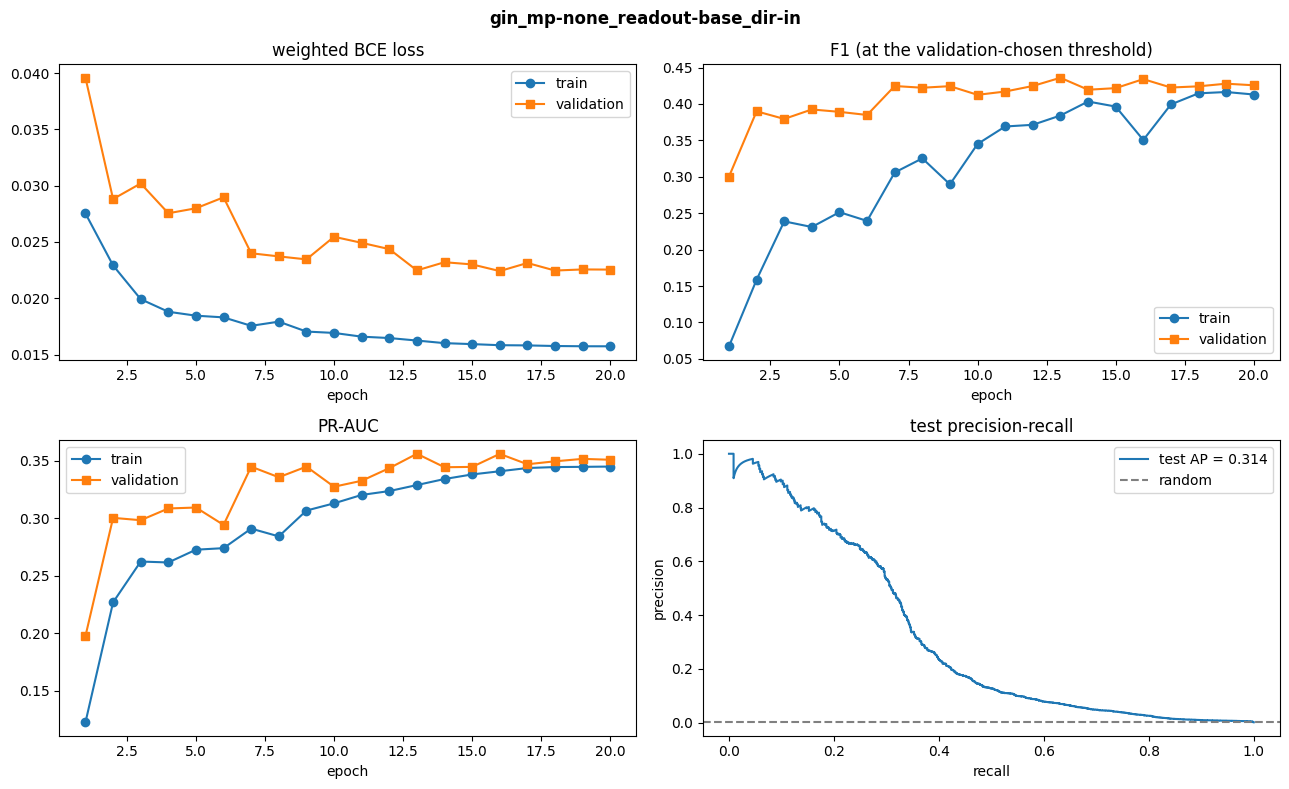

In [21]:
df = pd.DataFrame(history)
fig, ax = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle(RUN_NAME, fontweight='bold')

ax[0, 0].plot(df['epoch'], df['train_loss'], marker='o', label='train')
ax[0, 0].plot(df['epoch'], df['val_loss'], marker='s', label='validation')
ax[0, 0].set_title('weighted BCE loss')
ax[0, 0].set_xlabel('epoch')
ax[0, 0].legend()

ax[0, 1].plot(df['epoch'], df['train_f1'], marker='o', label='train')
ax[0, 1].plot(df['epoch'], df['val_f1'], marker='s', label='validation')
ax[0, 1].set_title('F1 (at the validation-chosen threshold)')
ax[0, 1].set_xlabel('epoch')
ax[0, 1].legend()

ax[1, 0].plot(df['epoch'], df['train_pr_auc'], marker='o', label='train')
ax[1, 0].plot(df['epoch'], df['val_pr_auc'], marker='s', label='validation')
ax[1, 0].set_title('PR-AUC')
ax[1, 0].set_xlabel('epoch')
ax[1, 0].legend()

precision, recall, _ = precision_recall_curve(y_test, p_test)
ax[1, 1].plot(recall, precision, label=f'test AP = {test_metrics["pr_auc"]:.3f}')
ax[1, 1].axhline(y_test.mean(), color='gray', linestyle='--', label='random')
ax[1, 1].set_title('test precision-recall')
ax[1, 1].set_xlabel('recall')
ax[1, 1].set_ylabel('precision')
ax[1, 1].legend()

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/curves.png', dpi=120)
plt.show()

## How to run the other configurations

Change only the knobs in Section 1 and re-run — the architecture, hyperparameters and training
recipe stay identical, so results are directly comparable (check that `invariant_params` is the
same in every `results.json`).

**Feature-set grid** (`MP_EDGE_FEATS` × `READOUT_EDGE_FEATS`):

| `MP_EDGE_FEATS` | `READOUT_EDGE_FEATS` | Meaning |
|---|---|---|
| `none` | `base` | **this run** — topology + node features build embeddings; classifier sees baseline txn features |
| `none` | `full` | same embeddings; classifier also sees GFP |
| `base` | `base` | standard edge-aware GIN (GINE) |
| `base` | `full` | GFP only at the decision layer |
| `full` | `full` | everything everywhere (paper-style GFP + GNN) |
| `base` | `gfp` | embeddings + structural summary, no raw txn attributes at the readout |

**Direction experiment:** repeat any row with `MP_DIRECTION = 'bidirectional'` (incoming vs
incoming + outgoing aggregation). **Causality experiment:** `TEMPORAL_SAMPLING = True`.

Each run writes `outputs/<run>/results.json`, `history.csv`, `best.pt`, `curves.png`.

In [22]:
import shutil
shutil.make_archive('/kaggle/working/outputs_gin_baseline_191026', 'zip', '/kaggle/working/outputs')

'/kaggle/working/outputs_gin_baseline_191026.zip'